# Posterior grid

This notebook mirrors `scripts/plot_bar1d_posterior_grid.py`.

It expects the calibration cases `1, 2, 3, 5, 6, 7` to be available under `results/`. If they are missing, set `generate_missing_cases = True` in the preparation cell and run the notebook once to build them with the `analytic` backend.

In [48]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from mpi4py import MPI

from statFEMx.config import Bar1DConfig
from statFEMx.fem.bar1d import solve_bar_1d
from statFEMx.statfem.bar1d import (
    build_projection_matrix,
    compute_posterior,
    estimate_hyperparameters,
    generate_synthetic_observations,
)
from statFEMx.uq.bar1d_mc import run_bar1d_mc
from statFEMx.uq.bar1d_pce import run_bar1d_pce


In [49]:
def setup_mpl() -> None:
    mpl.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "STIXGeneral"],
        "mathtext.fontset": "stix",
        "axes.labelsize": 16,
        "axes.titlesize": 14,
        "font.size": 13,
        "legend.fontsize": 10,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.minor.width": 0.6,
        "ytick.minor.width": 0.6,
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.minor.size": 2.5,
        "ytick.minor.size": 2.5,
        "legend.frameon": True,
        "legend.fancybox": False,
        "legend.edgecolor": "black",
        "legend.framealpha": 1.0,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


def run_case(output_path: Path, cal_case: int, *, backend: str = "analytic", obs_case: str = "nonlinear") -> None:
    cfg = Bar1DConfig()
    comm = MPI.COMM_SELF
    det = solve_bar_1d(cfg, cfg.mean_youngs_modulus, backend=backend, comm=MPI.COMM_SELF)
    mc = run_bar1d_mc(cfg, backend=backend, comm=comm)
    pce = run_bar1d_pce(cfg, backend=backend, comm=comm)
    obs = generate_synthetic_observations(cfg, obs_case=obs_case, cal_case=cal_case)
    P, P_active = build_projection_matrix(cfg, obs.sensor_coordinates)
    hp = estimate_hyperparameters(
        C_u_active_pc=pce.covariance[1:, 1:],
        P_active=P_active,
        C_e=obs.C_e,
        y_obs=obs.y_obs,
        mu_u_active_pc=pce.mean[1:],
        sensor_coordinates=obs.sensor_coordinates,
        nrep=obs.nrep,
    )
    posterior = compute_posterior(
        cfg,
        mu_u_active_pc=pce.mean[1:],
        C_u_active_pc=pce.covariance[1:, 1:],
        P_active=P_active,
        y_obs=obs.y_obs,
        C_e=obs.C_e,
        C_d=hp.C_d,
        rho=hp.rho,
        nrep=obs.nrep,
    )
    output_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez(
        output_path,
        node_coordinates=det.node_coordinates,
        deterministic_displacement=det.displacement,
        mc_mean=mc.mean,
        mc_std=mc.std,
        mc_tip_samples=mc.tip_samples,
        pce_mean=pce.mean,
        pce_covariance=pce.covariance,
        pce_tip_samples=pce.tip_samples,
        sensor_coordinates=obs.sensor_coordinates,
        y_obs=obs.y_obs,
        projection_matrix=P,
        rho=hp.rho,
        sig_d=hp.sig_d,
        l_d=hp.l_d,
        posterior_mean=posterior.mu_u_y,
        posterior_covariance=posterior.C_u_y,
        posterior_ci=posterior.ci_u_y,
        measurement_mean=posterior.mu_z,
        measurement_covariance=posterior.C_z,
        measurement_ci=posterior.ci_z,
    )


CASE_MAP = {
    1: (1, 11),
    2: (10, 11),
    3: (100, 11),
    5: (1, 33),
    6: (10, 33),
    7: (100, 33),
}


In [ ]:
setup_mpl()

results_dir = Path("../results")
cases = [1, 2, 3, 5, 6, 7]
generate_missing_cases = False
save_figure = False
output_path = results_dir / "bar1d_posterior_grid_notebook.png"

missing = [case for case in cases if not (results_dir / f"case_{case}.npz").exists()]
if missing and generate_missing_cases:
    for case in missing:
        path = results_dir / f"case_{case}.npz"
        run_case(path, case)
        print(f"saved {path}")

missing = [case for case in cases if not (results_dir / f"case_{case}.npz").exists()]
if missing:
    raise FileNotFoundError(f"Missing case files: {missing}. Set generate_missing_cases = True and rerun this cell.")


FileNotFoundError: Missing case files: [1, 2, 3, 5, 6, 7]. Set generate_missing_cases = True and rerun this cell.

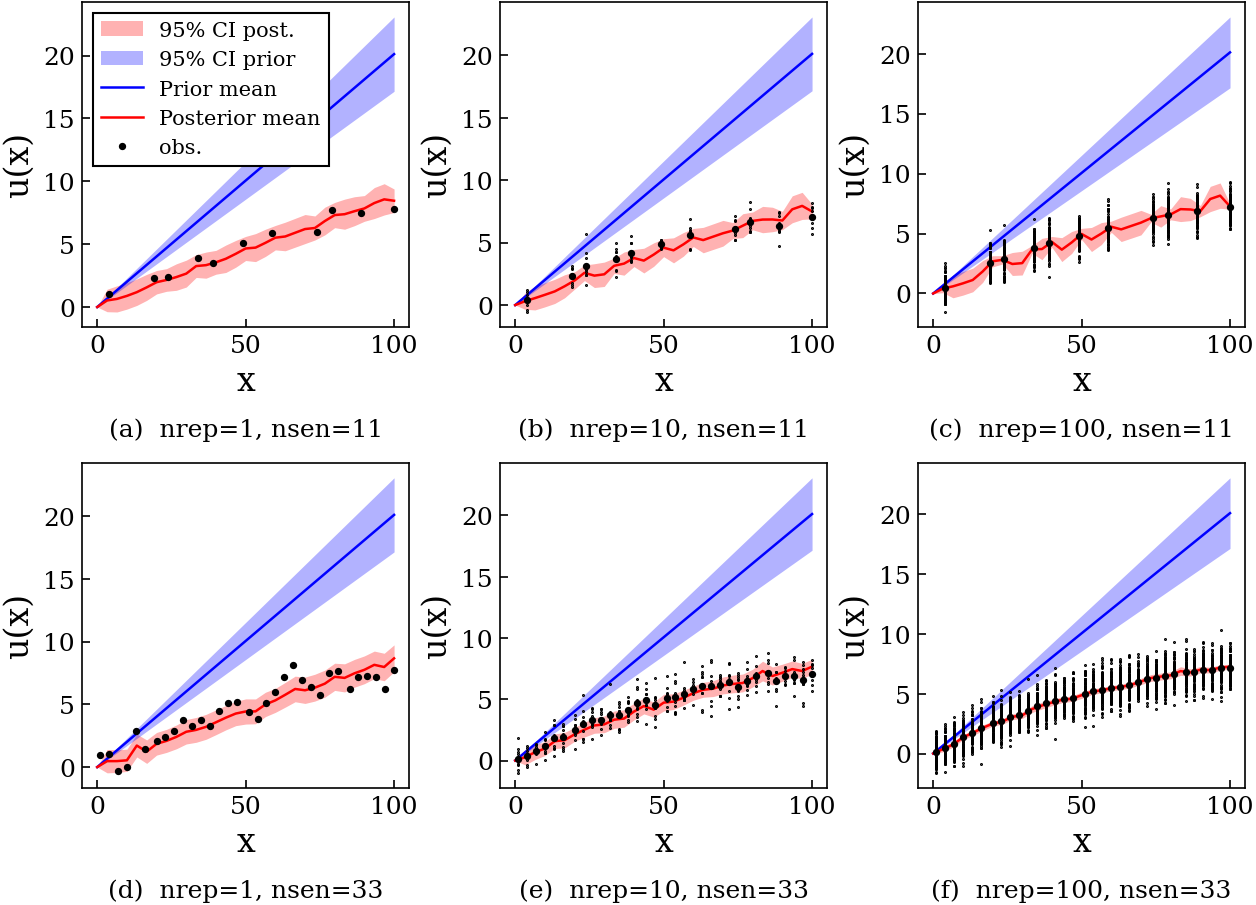

In [ ]:
%matplotlib inline

panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]
fig, axes = plt.subplots(2, 3, figsize=(10.0, 6.8))
axes = axes.ravel()

for i, case in enumerate(cases):
    data = np.load(results_dir / f"case_{case}.npz")
    x = np.asarray(data["node_coordinates"], dtype=float)
    prior_mean = np.asarray(data["pce_mean"], dtype=float)
    prior_cov = np.asarray(data["pce_covariance"], dtype=float)
    prior_std = np.sqrt(np.maximum(np.diag(prior_cov), 0.0))
    prior_ci = 1.96 * prior_std
    post_mean = np.asarray(data["posterior_mean"], dtype=float)
    post_ci = np.asarray(data["posterior_ci"], dtype=float)
    sensor_x = np.asarray(data["sensor_coordinates"], dtype=float)
    y_obs = np.asarray(data["y_obs"], dtype=float)
    ax = axes[i]

    ax.fill_between(x, post_mean - post_ci, post_mean + post_ci, color="red", alpha=0.30, linewidth=0.0, label="95% CI post." if i == 0 else None)
    ax.fill_between(x, prior_mean - prior_ci, prior_mean + prior_ci, color="blue", alpha=0.30, linewidth=0.0, label="95% CI prior" if i == 0 else None)
    ax.plot(x, prior_mean, color="blue", linewidth=1.2, label="Prior mean" if i == 0 else None)
    ax.plot(x, post_mean, color="red", linewidth=1.2, label="Posterior mean" if i == 0 else None)

    for j in range(sensor_x.size):
        ax.plot(np.full(y_obs.shape[1], sensor_x[j]), y_obs[j, :], ".", color="black", markersize=0.9)

    ax.plot(sensor_x, y_obs.mean(axis=1), "o", color="black", markersize=2.5, label="obs." if i == 0 else None)
    nrep, nsen = CASE_MAP[case]
    ax.set_xlabel("x")
    ax.set_ylabel("u(x)")
    ax.tick_params(direction="in")
    ax.grid(False)
    ax.text(0.5, -0.28, f"{panel_labels[i]}  nrep={nrep}, nsen={nsen}", transform=ax.transAxes, ha="center", va="top", fontsize=12)

axes[0].legend(loc="upper left")
fig.subplots_adjust(wspace=0.28, hspace=0.42)

if save_figure:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path)
    print(f"saved {output_path}")

plt.show()
